In [1]:
import pandas as pd 
import numpy as np

In [2]:
# Read data
df = pd.read_csv("powerplant_data.csv")
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [3]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [4]:
df.info()
# AT --> Temperature
# V ---> Vaccum
# AP --> Pressure
# RH --> Humidity
# PE --> Produced energy

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9568 entries, 0 to 9567
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AT      9568 non-null   float64
 1   V       9568 non-null   float64
 2   AP      9568 non-null   float64
 3   RH      9568 non-null   float64
 4   PE      9568 non-null   float64
dtypes: float64(5)
memory usage: 373.9 KB


In [5]:
# split features
X = df.drop(["PE"] , axis=1)
y = df["PE"]

In [6]:
# Train test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X , y , test_size=0.2 , random_state=42
) 

In [7]:
# Data Scaling 
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
import torch 
import torch.nn as nn

In [9]:
# Convering data to Tensors
X_train_tensor = torch.tensor(X_train_scaled ,dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values , dtype=torch.float32).view(-1,1)

X_test_tensor = torch.tensor(X_test_scaled , dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values , dtype=torch.float32).view(-1,1)

In [10]:
X_train_tensor

tensor([[ 0.7481,  0.7201, -0.3266, -0.4971],
        [ 0.8618,  1.2652, -0.9852,  0.8182],
        [ 0.9341,  1.5231,  0.3252,  0.8017],
        ...,
        [-0.2210, -0.8350,  0.3676, -0.8355],
        [ 0.9475,  1.1425, -0.4197, -0.4546],
        [-1.7736, -1.1905,  1.9252,  0.9184]])

In [11]:
from torch.utils.data import DataLoader , TensorDataset

train_dataset = TensorDataset(X_train_tensor , y_train_tensor)
test_dataset = TensorDataset(X_test_tensor , y_test_tensor)

In [12]:
# DataLoader
train_loader = DataLoader(train_dataset , batch_size=32,shuffle=True)
test_loader = DataLoader(test_dataset , batch_size=32)

### Deep Learning

In [13]:
# ANN architechture 
class ANN(nn.Module):
    def __init__(self):
        super(ANN,self).__init__()

        self.model = nn.Sequential(
            # 1st Hidden layer
            nn.Linear(X_train.shape[1],6),
    
            # 2nd Hidden layer
            nn.Linear(6,6),
            nn.ReLU(),
    
            # output layer
            nn.Linear(6,1),       
        )
    
    def forward(self,x):
        return self.model(x)

In [14]:
import torch.optim as optim

model = ANN()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

In [15]:
# Training ANN model
epochs = 100
training_loss = []
eval_loss = []
best_val_loss = float("inf")

for epoch in range (epochs):
    model.train()
    running_train_loss = 0.0
    running_val_loss = 0.0

    for xbatch , ybatch in train_loader:
        # Xbatch ==> featues of 1batch
        # Ybatch ==> labels of 1batch
        optimizer.zero_grad()        # Set gradient to zero
        
        output = model(xbatch)       # forward prop.......predict output for 1batch   
        loss = criterion(output , ybatch)  # Compute loss
        loss.backward()              # backward prop......compute gradient 
        optimizer.step()             # Update params 

        running_train_loss += loss.item()         # Loss is tensor ==> py float

    epoch_train_loss = running_train_loss / len(train_loader)     # 1 epoch loss
    training_loss.append(epoch_train_loss)
    
    # Evaluation loss
    with torch.no_grad():           # No gradient calculated
        model.eval()

        for xbatch , ybatch in test_loader:
            output = model(xbatch)
            loss = criterion(output , ybatch)
            running_val_loss += loss.item()             # Keeping in tenor for understanding

    epoch_eval_loss = running_val_loss / len(test_loader)
    eval_loss.append(epoch_eval_loss)

    print(f"epoch {epoch+1}/{epochs} ==> Training Loss : {epoch_train_loss} , Testing Loss : {epoch_eval_loss}")


    if epoch_eval_loss < best_val_loss:         # Saving best model
        best_eval_loss = epoch_eval_loss
        torch.save(model.state_dict(), "best_model.pt")  # pt & pth filetype
    

epoch 1/100 ==> Training Loss : 205591.392578125 , Testing Loss : 203469.2296875
epoch 2/100 ==> Training Loss : 196518.4400390625 , Testing Loss : 185213.94453125
epoch 3/100 ==> Training Loss : 166026.3193359375 , Testing Loss : 143046.9765625
epoch 4/100 ==> Training Loss : 117793.07809244792 , Testing Loss : 93476.77278645833
epoch 5/100 ==> Training Loss : 76088.22612304687 , Testing Loss : 62817.04140625
epoch 6/100 ==> Training Loss : 57400.72263997396 , Testing Loss : 53400.0791015625
epoch 7/100 ==> Training Loss : 52643.05559895833 , Testing Loss : 51083.1083984375
epoch 8/100 ==> Training Loss : 50715.419173177084 , Testing Loss : 49557.33922526042
epoch 9/100 ==> Training Loss : 49100.288883463545 , Testing Loss : 47857.398665364584
epoch 10/100 ==> Training Loss : 47073.47213541667 , Testing Loss : 45856.716634114586
epoch 11/100 ==> Training Loss : 44771.20682779948 , Testing Loss : 43505.32760416667
epoch 12/100 ==> Training Loss : 42015.21073404948 , Testing Loss : 4070

In [16]:
loss_df = pd.DataFrame({
    "Training loss" : training_loss,
    "Eval loss" : eval_loss
})

In [17]:
loss_df.head()

,Training loss,Eval loss
0,205591.392578,203469.229687
1,196518.440039,185213.944531
2,166026.319336,143046.976562
3,117793.078092,93476.772786
4,76088.226123,62817.041406


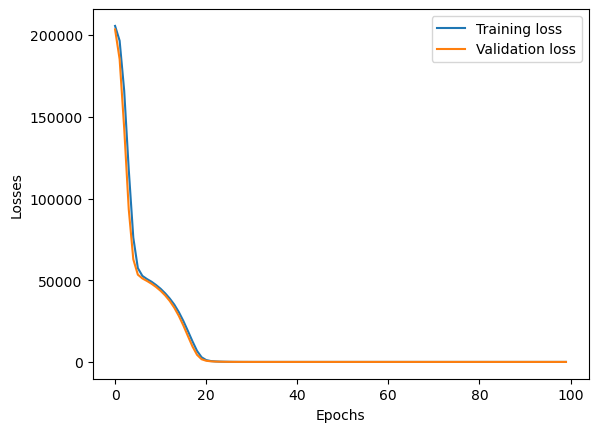

In [18]:
import matplotlib.pyplot as plt

# plt.figure(figsize=(12,8))

plt.plot(loss_df["Training loss"] , label="Training loss")
plt.plot(loss_df["Eval loss"] , label="Validation loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")
plt.legend()

In [19]:
# Load best model
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [20]:
# Model Evaluation 
model.eval()
with torch.no_grad():
    train_pred = model(X_train_tensor)
    test_pred = model(X_test_tensor)
    
    train_mse_loss = criterion(train_pred , y_train_tensor)
    test_mse_loss = criterion(test_pred , y_test_tensor)

print("Training MSE Loss : " , train_mse_loss.item())
print("Testing MSE Loss : " , test_mse_loss.item())

Training MSE Loss :  18.97107696533203
Testing MSE Loss :  17.320932388305664


In [21]:
from sklearn.metrics import r2_score
print("r2 score : ", r2_score(test_pred , y_test))

r2 score :  0.9340978910174897


In [22]:
pred_df = pd.DataFrame(test_pred.numpy() , columns=["pred_val"])
actual_df = pd.DataFrame(y_test.values , columns=["actual_val"])

pd.concat([pred_df,actual_df] , axis=1)

,pred_val,actual_val
0,435.845459,433.27
1,436.777435,438.16
2,458.797485,458.42
3,476.200653,480.82
4,438.587128,441.41
...,...,...
1909,448.998688,456.70
1910,432.707916,438.04
1911,467.382843,467.80
1912,432.283508,437.14


In [28]:
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor(random_state=42)
model.fit(X_train_scaled , y_train)

DecisionTreeRegressor(random_state=42)

In [29]:
y_pred = model.predict(X_test_scaled)

print("r2_score" , r2_score(y_pred , y_test))

r2_score 0.9317601823362276
